# 0.1 Data Loading & Exploration

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
#To suppress all warnings
import warnings
warnings.filterwarnings('ignore')

## 1. Load Titanic dataset

In [5]:
df = sns.load_dataset('titanic')

## 2. Display the first 10 rows.

In [6]:
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


## 3. Count missing values in each column 

In [7]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## 4. Display column names

In [8]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

## 5. Show unique values in the embarked column

In [10]:
df['embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

## 0.2 Data Cleaning

## 1. Fill missing embarked with the most frequent value. 

In [12]:
df['embarked'].fillna(df['embarked'].mode())

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: embarked, Length: 891, dtype: object

## 2. Convert sex and class to categorical type.  

In [22]:
df['sex'] = df['sex'].astype('category')
df['class'] = df['class'].astype('category')
df.dtypes

survived          int64
pclass            int64
sex            category
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
family_size       int64
dtype: object

## 3. Create a new column family_size= sibsp + parch + 1.

In [16]:
df['family_size'] = df['sibsp'] + df['parch'] + 1 
df['family_size']

0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: family_size, Length: 891, dtype: int64

## 4. Cap fare at the 99th percentile to reduce outlier impact.

In [29]:
df['fare_capped'] = df['fare'].clip(upper=df['fare'].quantile(0.99))
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size,fare_capped
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2,7.2500
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2,71.2833
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1,7.9250
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2,53.1000
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1,8.0500


# 0.3 Visualization

## 1. Pairplot of ['age', 'fare', 'sibsp'] colored by survived. 

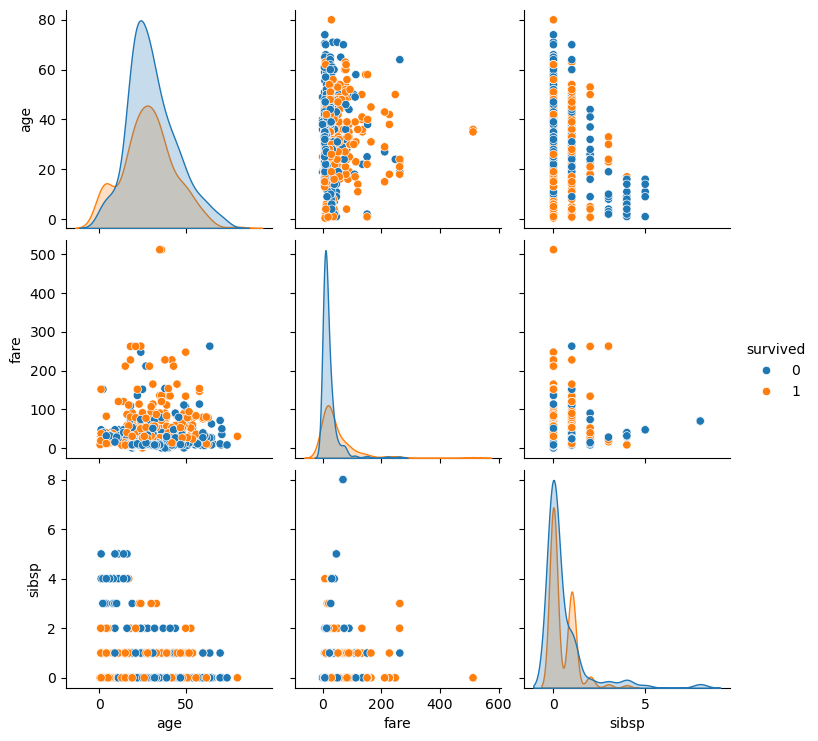

In [32]:

sns.pairplot(df, vars=['age', 'fare', 'sibsp'], hue='survived', diag_kind='kde')
plt.show()

## 2. Heatmap of correlations for numeric columns. 

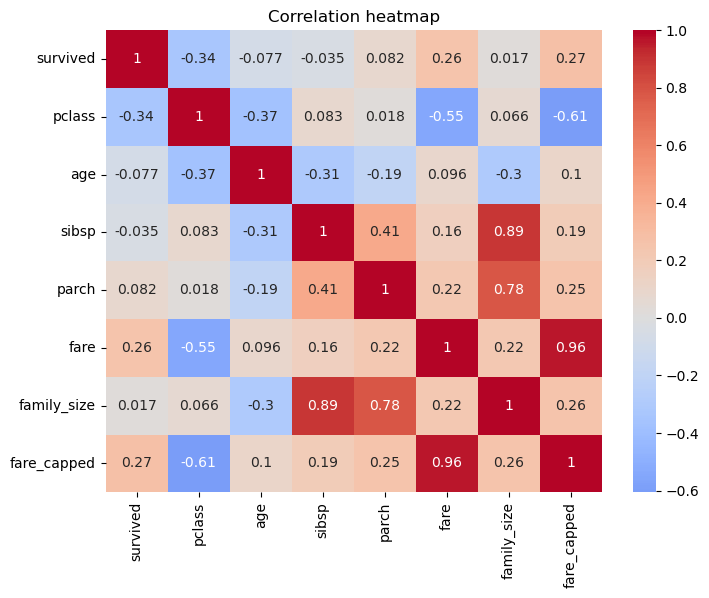

In [39]:
plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=np.number).columns

sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation heatmap')
plt.show()

## 3. Scatter plot of age vs fare, colored by survived. 

Text(0.5, 1.0, 'age vs fare')

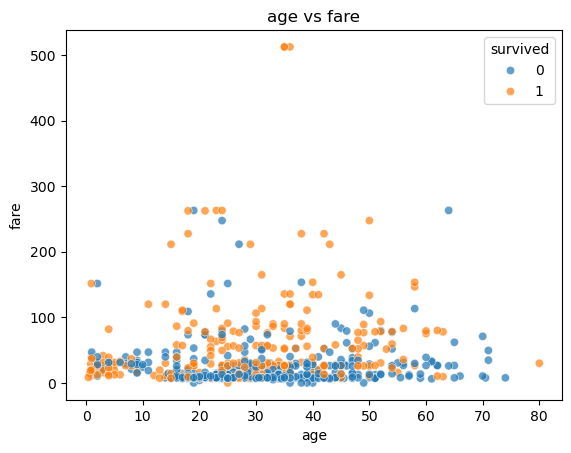

In [42]:
sns.scatterplot(x='age', y='fare', hue='survived', data=df, alpha=0.7)
plt.title('age vs fare')

## 4. Plot a histogram of age with 30 bins and KDE

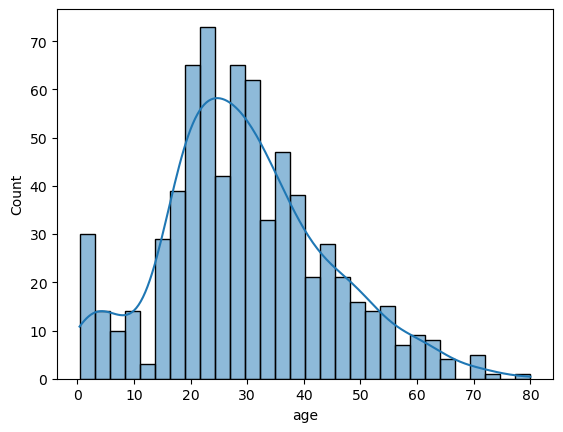

In [45]:
sns.histplot(df['age'], bins=30, kde=True)
plt.show()